# Kernel Principal Component Analysis (KPCA)

This notebook applies **Kernel Principal Component Analysis (KPCA)** to the processed
TCGA PANCAN gene-expression dataset. The objective is to evaluate KPCA as a nonlinear
dimension reduction method for multiclass cancer classification.

Two kernel functions are evaluated:
- Radial Basis Function (RBF) kernel
- Polynomial kernel (degree = 2)

Model performance is evaluated using **Repeated Stratified 5-Fold Cross-Validation** with
**5 repetitions** (25 train/test splits). To prevent data leakage, feature standardization
and KPCA are fitted exclusively on the training data within each cross-validation split.

In addition to predictive performance, this notebook evaluates the computational
efficiency, representation quality, and reconstruction ability of KPCA.

## Workflow

1. Load the processed dataset.
2. Import the required libraries.
3. Define the cross-validation strategy:
   - Repeated Stratified 5-Fold Cross-Validation (5 folds × 5 repetitions).
4. Define the kernel configurations:
   - RBF kernel
   - Polynomial kernel (degree = 2)
5. Define the numbers of kernel principal components:
   - n_components = [5, 10, 25, 50]
6. For each kernel configuration:
   - For each value of n_components:
     - For each cross-validation split:
       - Split the data into training and test sets.
       - Fit StandardScaler on the training data.
       - Transform the training and test data.
       - Fit KPCA on the standardized training data.
       - Transform the training and test data.
       - Train the Logistic Regression classifier.
       - Generate predictions.
       - Compute and store: Accuracy, Macro Precision, Macro Recall, Macro F1 Score,
         Macro ROC-AUC.
       - Record: KPCA fit time, KPCA transform time.
       - Reconstruct the standardized test data using KernelPCA.inverse_transform()
         (approximate pre-image method).
       - Compute and store the reconstruction error (MSE).
7. Aggregate the results across all cross-validation splits for each kernel
   configuration and value of n_components by computing their mean and standard
   deviation.
8. Save the evaluation results:
   - KPCA_{kernel}_classification_summary.csv
   - KPCA_{kernel}_reconstruction_summary.csv
   - KPCA_{kernel}_runtime_summary.csv
9. Evaluate representation quality using the full processed dataset:
   - Standardize the entire dataset.
   - Fit KPCA (2 components) for each kernel and project the data.
   - Compute the silhouette score on the projected embedding.
   - Generate and save 2D embedding scatter plots for each kernel.

## 1. Data and Imports

In [1]:
# Import required libraries
import warnings
warnings.filterwarnings("ignore")

import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.decomposition import KernelPCA
from sklearn.metrics import silhouette_score


random_state = 42

In [2]:
# Set project root
import sys
from pathlib import Path

project_root = Path("..").resolve()
sys.path.insert(0, str(project_root))

In [3]:
# Import custom evaluation functions
from src.evaluation import evaluate_classification, summarize_results

In [4]:
# Load the processed dataset
X = pd.read_csv(project_root / "data" / "processed" / "X_processed.csv")
X = X.iloc[:, 1:]
y = pd.read_csv(project_root / "data" / "processed" / "y_processed.csv",index_col=0).iloc[:, 0]

## 2. Define Experimental Settings

In [5]:
# Cross-validation strategy
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=random_state)

In [6]:
# Numbers of principal components to evaluate
n_components_list = [5, 10, 25, 50]

In [7]:
# Kernel configurations to evaluate
gamma = 1 / X.shape[1]

kernel_configs = [
    {
        "name": "RBF",
        "kernel": "rbf",
        "gamma": gamma,
    },
    {
        "name": "Polynomial",
        "kernel": "poly",
        "degree": 2,
        "gamma": gamma,
        "coef0": 1,
    },
]

In [8]:
# Classifier
classifier = LogisticRegression(max_iter=1000, random_state=random_state)

## 3. PCA Classification Pipeline

In [9]:
# Start total timer
total_start = time.perf_counter()

# Initialize result storage

# CLassification Performance
classification_results = {}
classification_summary = {}

# Reconstruction
reconstruction_results = {}
reconstruction_summary = {}

# Runtime
runtime_results = {}
runtime_summary = None

# kernel
for kernel_config in kernel_configs:

    kernel_name = kernel_config["name"]

    print(f"Kernel: {kernel_name}")

    classification_results[kernel_name] = {}
    classification_summary[kernel_name] = {}
    reconstruction_results[kernel_name] = {}
    reconstruction_summary[kernel_name] = {}

    runtime_results[kernel_name] = {}

    # Evaluate PCA using repeated stratified cross-validation
    for n_components in n_components_list:

        print(f"\nEvaluating KPCA ({kernel_name}) "
              f"with {n_components} components"
        )
    
        # Start timer for this value of n_components
        component_start = time.perf_counter()

        # Store results for all CV splits
        classification_split_results = []
        reconstruction_split_results = []

        fit_times = []
        transform_times = []
        kpca_process_times = []
        
        # Cross-validation loop
        for split_idx, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):

            # Split data
            X_train = X.iloc[train_idx]
            X_test = X.iloc[test_idx]

            y_train = y.iloc[train_idx]
            y_test = y.iloc[test_idx]
    
            # Standardisation
            scaler = StandardScaler()

            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)

            # KPCA
            kpca = KernelPCA(
                n_components=n_components,
                kernel=kernel_config["kernel"],
                gamma=kernel_config["gamma"],
                degree=kernel_config.get("degree", 3),
                coef0=kernel_config.get("coef0", 1),
                fit_inverse_transform=True,
                random_state=random_state,
            )

            # Fit time
            fit_start = time.perf_counter()

            X_train_kpca = kpca.fit_transform(X_train_scaled)

            fit_time = time.perf_counter() - fit_start
            fit_times.append(fit_time)

            # Transform time
            transform_start = time.perf_counter()

            X_test_kpca = kpca.transform(X_test_scaled)

            transform_time = time.perf_counter() - transform_start
            transform_times.append(transform_time)

            # KPCA process time (fit + transform)
            kpca_process_time = fit_time + transform_time
            kpca_process_times.append(kpca_process_time)

            # Classification

            classifier.fit(X_train_kpca, y_train)
        
            y_pred = classifier.predict(X_test_kpca)
            y_prob = classifier.predict_proba(X_test_kpca)

            metrics = evaluate_classification(
                y_test,
                y_pred,
                y_prob,
            )

            metrics["Split"] = split_idx
            classification_split_results.append(metrics)

            # Reconstruction

            X_test_reconstructed = kpca.inverse_transform(X_test_kpca)
            X_test_reconstructed = scaler.inverse_transform(X_test_reconstructed)

            reconstruction_error = np.mean(
                (X_test.to_numpy() - X_test_reconstructed) ** 2
            )

            reconstruction_split_results.append(
                {
                    "Split": split_idx,
                    "Reconstruction MSE": reconstruction_error,
                }
            )


        # Store classification results
        classification_results[kernel_name][n_components] = pd.DataFrame(classification_split_results)
    
        classification_summary[kernel_name][n_components] = summarize_results([{k: v for k, v in m.items() if k != "Split"} for m in classification_split_results])
        
        # Store reconstruction results
        reconstruction_results[kernel_name][n_components] = pd.DataFrame(reconstruction_split_results)

        reconstruction_summary[kernel_name][n_components] = (
            reconstruction_results[kernel_name][n_components]
            .drop(columns="Split")
            .agg(["mean", "std"])
            .T
            .rename(columns={"mean": "Mean", "std": "Std"})
        )

        # Runtime
        component_end = time.perf_counter()

        runtime_results[kernel_name][n_components] = {
            "Fit Time Mean (s)": np.mean(fit_times),
            "Fit Time Std (s)": np.std(fit_times, ddof=1),
            "Transform Time Mean (s)": np.mean(transform_times),
            "Transform Time Std (s)": np.std(transform_times, ddof=1),
            "KPCA Process Time Mean (s)": np.mean(kpca_process_times),
            "KPCA Process Time Std (s)": np.std(kpca_process_times, ddof=1),
            "Total Runtime (s)": component_end - component_start,
        }

        print(
            f"KPCA ({kernel_name}, "
            f"{n_components:>2} components): "
        f"{runtime_results[kernel_name][n_components]['Total Runtime (s)']:.2f} seconds"
        )


# Runtime summary
runtime_summary = {}

for kernel_name in runtime_results:

    runtime_summary[kernel_name] = (
        pd.DataFrame(runtime_results[kernel_name]).T
    )

    runtime_summary[kernel_name].index.name = "n_components"

# Total runtime
total_end = time.perf_counter()

print(f"\nTotal runtime: {(total_end - total_start)/60:.2f} minutes")

Kernel: RBF

Evaluating KPCA (RBF) with 5 components
KPCA (RBF,  5 components): 133.24 seconds

Evaluating KPCA (RBF) with 10 components
KPCA (RBF, 10 components): 139.43 seconds

Evaluating KPCA (RBF) with 25 components
KPCA (RBF, 25 components): 135.00 seconds

Evaluating KPCA (RBF) with 50 components
KPCA (RBF, 50 components): 135.59 seconds
Kernel: Polynomial

Evaluating KPCA (Polynomial) with 5 components
KPCA (Polynomial,  5 components): 129.09 seconds

Evaluating KPCA (Polynomial) with 10 components
KPCA (Polynomial, 10 components): 131.52 seconds

Evaluating KPCA (Polynomial) with 25 components
KPCA (Polynomial, 25 components): 132.18 seconds

Evaluating KPCA (Polynomial) with 50 components
KPCA (Polynomial, 50 components): 132.55 seconds

Total runtime: 17.81 minutes


## 4. Results Summary

In [10]:
# Combine classification summaries
classification_summary_df = {}

for kernel_name in classification_summary:

    classification_summary_df[kernel_name] = pd.concat(
        classification_summary[kernel_name],
        names=["n_components", "Metric"]
    )

for kernel_name in classification_summary_df:

    print(f"\n{kernel_name}")
    print(classification_summary_df[kernel_name])


RBF
                                  Mean       Std
n_components Metric                             
5            Accuracy         0.936079  0.017598
             Macro Precision  0.960768  0.011841
             Macro Recall     0.922098  0.022153
             Macro F1         0.938474  0.017755
             Macro ROC AUC    0.995684  0.001798
10           Accuracy         0.965789  0.014211
             Macro Precision  0.981886  0.006553
             Macro Recall     0.956575  0.017555
             Macro F1         0.967882  0.012900
             Macro ROC AUC    0.999726  0.000324
25           Accuracy         0.967789  0.014607
             Macro Precision  0.982633  0.007230
             Macro Recall     0.958863  0.017777
             Macro F1         0.969514  0.013316
             Macro ROC AUC    0.999811  0.000251
50           Accuracy         0.971028  0.012622
             Macro Precision  0.984298  0.006048
             Macro Recall     0.962772  0.015658
             Ma

In [11]:
# Combine reconstruction summaries
reconstruction_summary_df = {}

for kernel_name in reconstruction_summary:

    reconstruction_summary_df[kernel_name] = pd.concat(
        reconstruction_summary[kernel_name],
        names=["n_components", "Metric"]
    )

for kernel_name in reconstruction_summary_df:

    print(f"\n{kernel_name}")
    print(reconstruction_summary_df[kernel_name])


RBF
                                     Mean       Std
n_components Metric                                
5            Reconstruction MSE  1.785459  0.025416
10           Reconstruction MSE  1.785306  0.025416
25           Reconstruction MSE  1.785259  0.025415
50           Reconstruction MSE  1.785244  0.025415

Polynomial
                                     Mean       Std
n_components Metric                                
5            Reconstruction MSE  1.771192  0.025144
10           Reconstruction MSE  1.770245  0.025102
25           Reconstruction MSE  1.769964  0.025100
50           Reconstruction MSE  1.769877  0.025099


In [12]:
for kernel_name in runtime_summary:

    print(f"\n{kernel_name}")
    print(runtime_summary[kernel_name])


RBF
              Fit Time Mean (s)  Fit Time Std (s)  Transform Time Mean (s)  \
n_components                                                                 
5                      1.876627          0.151126                 0.173797   
10                     2.010755          0.165692                 0.172338   
25                     1.971899          0.131877                 0.165964   
50                     1.988653          0.111978                 0.168437   

              Transform Time Std (s)  KPCA Process Time Mean (s)  \
n_components                                                       
5                           0.012890                    2.050424   
10                          0.013174                    2.183093   
25                          0.008909                    2.137862   
50                          0.007890                    2.157090   

              KPCA Process Time Std (s)  Total Runtime (s)  
n_components                                            

In [13]:
# Save Results

# Output directories
metrics_dir = Path("../results/metrics")
timings_dir = Path("../results/timings")

metrics_dir.mkdir(parents=True, exist_ok=True)
timings_dir.mkdir(parents=True, exist_ok=True)

# Save summaries
for kernel_name in kernel_configs:

    name = kernel_name["name"]

    classification_summary_df[name].to_csv(
        metrics_dir /
        f"KPCA_{name}_classification_summary.csv"
    )

    reconstruction_summary_df[name].to_csv(
        metrics_dir /
        f"KPCA_{name}_reconstruction_summary.csv"
    )

    runtime_summary[name].to_csv(
        timings_dir /
        f"KPCA_{name}_runtime_summary.csv"
    )

print("Results saved successfully.")

Results saved successfully.


# 5. Representation Quality

In [14]:
# Standardize the full dataset
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

In [15]:
# Figure Directories
figure_dir = Path("../figures/KPCA")
figure_dir.mkdir(parents=True, exist_ok=True)

In [16]:
# Representation Quality: Silhouette Score across component counts
silhouette_results = []

for kernel_config in kernel_configs:
    kernel_name = kernel_config["name"]
    print(f"\nEvaluating silhouette for {kernel_name}")

    for n_components in n_components_list:
        kpca_repr = KernelPCA(
            n_components=n_components,
            kernel=kernel_config["kernel"],
            gamma=kernel_config["gamma"],
            degree=kernel_config.get("degree", 3),
            coef0=kernel_config.get("coef0", 1),
            random_state=random_state,
        )
        X_kpca_repr = kpca_repr.fit_transform(X_scaled)

        score = silhouette_score(X_kpca_repr, y)

        silhouette_results.append({
            "Kernel": kernel_name,
            "n_components": n_components,
            "Silhouette Score": score,
        })

# Save results
silhouette_df = pd.DataFrame(silhouette_results)
silhouette_df.to_csv(
    metrics_dir / "KPCA_silhouette_by_components.csv",
    index=False,
)
print(silhouette_df)


Evaluating silhouette for RBF

Evaluating silhouette for Polynomial
       Kernel  n_components  Silhouette Score
0         RBF             5          0.379140
1         RBF            10          0.312136
2         RBF            25          0.223151
3         RBF            50          0.182150
4  Polynomial             5          0.404880
5  Polynomial            10          0.342880
6  Polynomial            25          0.270812
7  Polynomial            50          0.229727


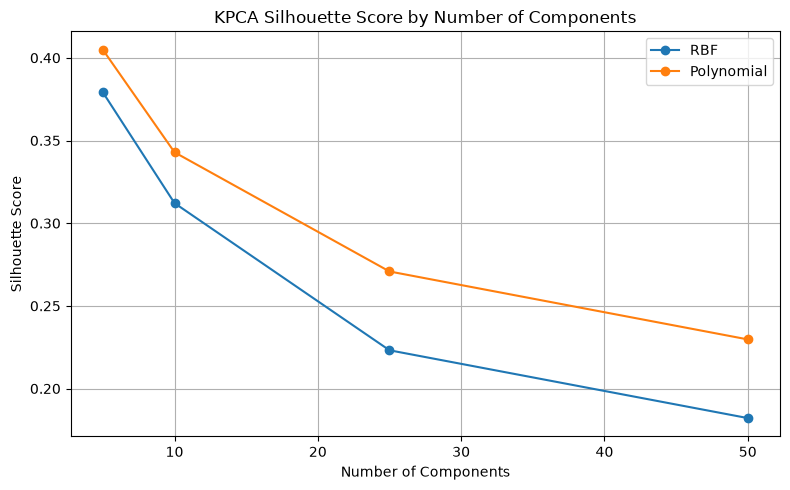

In [17]:
plt.figure(figsize=(8, 5))
for kernel_name in silhouette_df["Kernel"].unique():
    subset = silhouette_df[silhouette_df["Kernel"] == kernel_name]
    plt.plot(
        subset["n_components"],
        subset["Silhouette Score"],
        marker="o",
        label=kernel_name,
    )
plt.xlabel("Number of Components")
plt.ylabel("Silhouette Score")
plt.title("KPCA Silhouette Score by Number of Components")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(
    figure_dir / "silhouette_by_components.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


Evaluating RBF


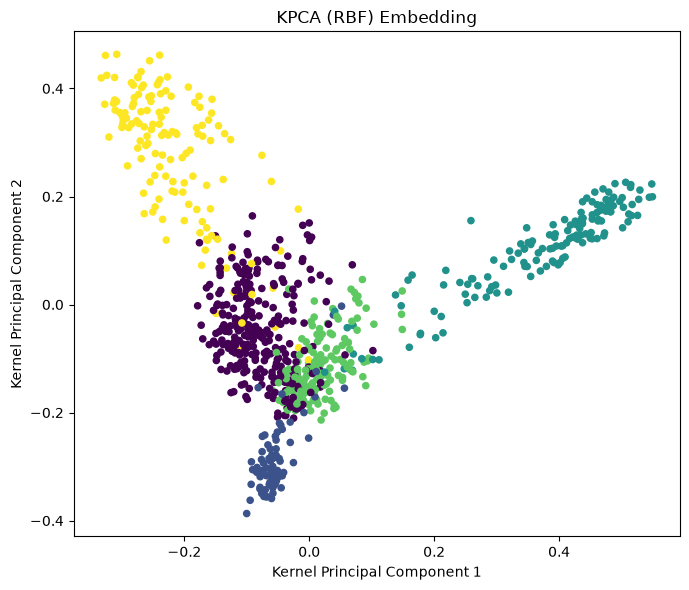


Evaluating Polynomial


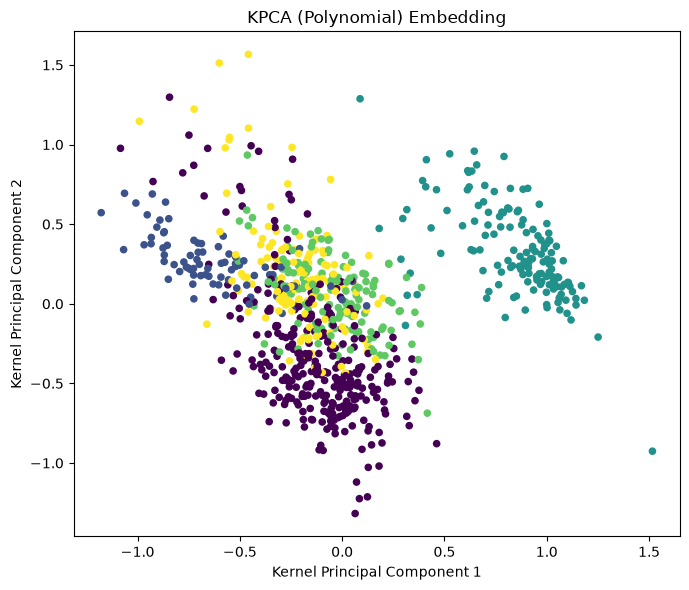

In [18]:
# Representation evaluation
representation_results = []

for kernel_config in kernel_configs:

    kernel_name = kernel_config["name"]

    print(f"\nEvaluating {kernel_name}")

    kernel_dir = figure_dir / kernel_name
    kernel_dir.mkdir(parents=True, exist_ok=True)

    kpca = KernelPCA(
        n_components=2,
        kernel=kernel_config["kernel"],
        gamma=kernel_config["gamma"],
        degree=kernel_config.get("degree", 3),
        coef0=kernel_config.get("coef0", 1),
        random_state=random_state,
    )

    X_embedding = kpca.fit_transform(X_scaled)

    silhouette = silhouette_score(
        X_embedding,
        y
    )

    representation_results.append(
        {
            "Kernel": kernel_name,
            "Silhouette Score": silhouette,
        }
    )

    plt.figure(figsize=(7,6))

    scatter = plt.scatter(
        X_embedding[:,0],
        X_embedding[:,1],
        c=y.astype("category").cat.codes,
        s=20,
    )

    plt.xlabel("Kernel Principal Component 1")
    plt.ylabel("Kernel Principal Component 2")

    plt.title(
        f"KPCA ({kernel_name}) Embedding"
    )

    plt.tight_layout()

    plt.savefig(
        kernel_dir /
        "embedding.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

In [20]:
# Save Representation Summary
representation_df = pd.DataFrame(
    representation_results
)

print(representation_df)

representation_df.to_csv(
    metrics_dir /
    "KPCA_representation_quality.csv",
    index=False,
)

       Kernel  Silhouette Score
0         RBF          0.347115
1  Polynomial          0.162447
